# Benchmark Analysis

This notebook uses the benchmark analysis API from `examples/benchmark_runner.py` to:

1. load a full benchmark session
2. group runs by restart family and select the top `K` groups by minimal `best_loss`
3. plot aggregate loss lines for the selected subset
4. load the best model from each selected restart group and scatter plot samples


In [40]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

from benchmark_runner import (
    entries_to_frame,
    entry_arrays,
    get_lines,
    import_runtime_dependencies,
    load_entry_model,
    load_experiment_entries,
    restart_group_columns,
)


In [41]:
session_dir = Path('./results/ce_two_spirals_anderson_big/benchmark_20260715_173225/')
# session_dir = Path('./results/ce_checkerboard_big/benchmark_20260716_011405/')
# session_dir = Path('./results/mmd_8gaussians_big/benchmark_20260717_002534/')

# clipping gradient, not update vector; anderson
#session_dir = Path('./results/ce_two_spirals_anderson/benchmark_20260715_143611/')
#session_dir_adaptive = Path('./results/ce_two_spirals_anderson_adaptive/benchmark_20260715_154313/')
# clipping gradient, not update vector; smaller clipping
#session_dir_ngd = Path('./results/ce_two_spirals_arch_search_clipping/benchmark_20260713_232123/')
# clipping gradient, not update vector; larger clipping
# session_dir = Path('./results/ce_two_spirals_arch_search_clipping/benchmark_20260713_144235/')
entries = load_experiment_entries(session_dir)
#entries += load_experiment_entries(session_dir_ngd)
#entries += load_experiment_entries(session_dir_adaptive)
# session_dir = Path('./results/ce_two_spirals_arch_search_clipping/benchmark_20260708_203116/')
# entries += load_experiment_entries(session_dir)
for e in entries:
    e['method_kwargs'].pop('max_iterations')

for entry in entries:
    if 'bw_multipliers' in entry['problem']['functional']:
        entry['problem']['functional']['bw_multipliers'] = tuple(entry['problem']['functional']['bw_multipliers'])

df_all = entries_to_frame(entries)

In [42]:
arch_cols = [colname for colname in df_all.columns if 'architecture' in colname]

cmaps = ['Reds', 'Blues', 'Oranges']

for arch_param, df_arch in df_all.groupby(arch_cols):
    _, _, w_hidden, n_hidden, _, n_steps, _, _, _ = arch_param
    group_cols = restart_group_columns(df_arch)
    best_k_with_reruns = df_arch.\
        groupby(group_cols).\
        apply(lambda _df: _df['best_loss'].min(), include_groups=False)
        

In [43]:
def select_top_k_restart_groups(entries, k):
    frame = entries_to_frame(entries) 
    frame = frame.query(
        "`method_kwargs.step_size` == 0.01"
        #" and "
        #" `method_kwargs.natural_grad_clipping_threshold` == 0.05" 
        " and "
        "   ("
        "     method == 'ngd'" 
        "    )" 
        "    or " 
        "   ("
        "    method == 'anderson'"
        "    and `method_kwargs.relaxation` == 1.0"
        # "    and `method_kwargs.regularization_method` == 'adaptive'"
        # "     and `method_kwargs.regularization_factor` == 1e-5"
        "   )"
    )
    # frame = frame.query(
    #     "`method_kwargs.step_size` == 0.01"
    #     " and `method_kwargs.natural_grad_clipping_threshold` == 0.5"
    #     " and ("
    #     "    ("
    #     "     `method` == 'anderson'"
    #     "     and `method_kwargs.regularization_method` == 'adaptive'"
#   #       "     and `method_kwargs.relaxation` == 5.0"
    #     "     and `method_kwargs.regularization_factor` == 1e-4"
    #     "    )"
    #     "     or "
    #     "    (`method` == 'ngd')"
    #     ")"
    # )

    # frame = frame.query("`method_kwargs.linear_solver_regularization` >= 0.01 and `method_kwargs.step_size` == 0.01 and `method_kwargs.natural_grad_clipping_threshold` == .1")
    # frame = frame.query("`method_kwargs.natural_grad_clipping_threshold` <= 10.0 and `method_kwargs.linear_solver_regularization` >= 0.001")
    # frame = frame.query(
    #     "`architecture.rhs.dim_hidden` == 64"
    #     " and `method_kwargs.natural_grad_clipping_threshold` == .5 "
    #     " and `method_kwargs.linear_solver_regularization` >= 0.001" )
    # frame = frame.query('`architecture.rhs.n_hidden` == 1 and `architecture.rhs.dim_hidden` == 16 and best_loss > best_loss.quantile(0.02)')
    group_cols = restart_group_columns(frame)

    if not group_cols:
        summary = frame[['entry_index', 'best_loss']].copy()
        summary['group_rank'] = 0
        return entries, summary

    summary = (
        frame.groupby(group_cols, sort=False, dropna=False, as_index=False)
        .agg(
            final_loss=('best_iteration', 'min'),
            n_restarts=('entry_index', 'count'),
        )
        .sort_values('final_loss', ascending=True, kind='stable')
        .head(k)
        # .reset_index(drop=True)
    )
    summary['group_rank'] = np.arange(len(summary))

    selected_frame = frame.merge(summary[group_cols], on=group_cols, how='inner')
    selected_indices = selected_frame['entry_index'].tolist()
    subset_entries = [entries[index] for index in selected_indices]
    return subset_entries, summary


def best_entry_per_restart_group(entries):
    frame = entries_to_frame(entries)
    group_cols = restart_group_columns(frame)

    if not group_cols:
        if not entries:
            return []
        best_index = int(frame['best_loss'].idxmin())
        return [entries[int(frame.loc[best_index, 'entry_index'])]]

    best_row_indices = (
        frame.groupby(group_cols, sort=False, dropna=False)['best_loss']
        .idxmin()
        .tolist()
    )
    entry_indices = frame.loc[best_row_indices, 'entry_index'].tolist()
    return [entries[int(index)] for index in entry_indices]


In [44]:
top_k = 25
subset_entries, subset_summary = select_top_k_restart_groups(entries, top_k)
best_entries = best_entry_per_restart_group(subset_entries)

print(f'selected {len(subset_entries)} entries across {len(best_entries)} restart groups')



selected 102 entries across 17 restart groups


In [45]:
def plot_line_groups(groups):
    for group in groups:
        fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')

        for line in group['lines']:
            style = line.get('style', {})
            color = style.get('color')
            linestyle = style.get('linestyle', '-')
            linewidth = style.get('linewidth', 1.5)

            if 'loss_mean' in line:
                x = np.arange(len(line['loss_mean'])) 
                ax.plot(
                    x,
                    line['loss_mean'],
                    label=line['label'],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )
                if 'loss_lower' in line and 'loss_upper' in line:
                    ax.fill_between(
                        x,
                        line['loss_lower'],
                        line['loss_upper'],
                        color=color,
                        alpha=0.2,
                    )
            else:
                loss = np.asarray(line['loss'], dtype=float)
                x = np.arange(len(loss))
                ax.plot(
                    x,
                    loss - df_all['best_loss'].min(),
                    label=line['label'],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )

        ax.set_title(group['title'])
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.set_ylim(
            bottom=0.1,
            top=1.5, )
        ax.grid()
        fig.legend(loc='outside center right')
        return fig


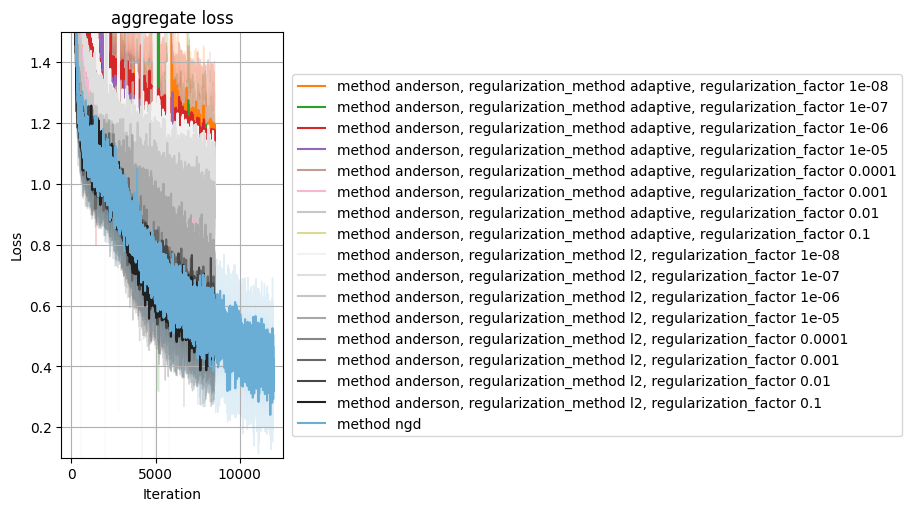

In [46]:
style_channels = {
    'colormap': ['tab20', 'Greys', 'Blues'],
    'linestyle': ['-', '--', ':', '-.'],
}
param_to_channel = {
    'method': 'cmap', 
    'regularization_factor': 'color',
    'regularization_method': 'cmap' }

groups = get_lines(subset_entries, style_channels=style_channels, style_channel_map=param_to_channel)
fig = plot_line_groups(groups)
fig.savefig(f"convergence.pdf")
plt.show()

In [47]:
def scatter_best_entries(entries, checkpoint_key='best', n_samples=512):
    if not entries:
        return

    deps = import_runtime_dependencies()
    ncols = min(3, len(entries))
    nrows = int(np.ceil(len(entries) / ncols))
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4 * nrows),
        layout='constrained',
    )
    axs = np.atleast_1d(axs).ravel()

    for ax, entry in zip(axs, entries, strict=False):
        model = load_entry_model(entry, key=checkpoint_key)
        samples = model.sample(n_samples, deps['nnx'].Rngs(0))

        if samples.shape[-1] >= 2:
            ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.7)
            ax.set_xlabel('x[0]')
            ax.set_ylabel('x[1]')
        else:
            ax.hist(samples[:, 0], bins=40)

        ax.set_title(
            f"{entry['run_id']} {entry['method']} r{entry['restart_index']}\n"
            f"best_loss={entry.get('best_loss', np.nan):.3e}, iter={entry.get('best_iteration')}"
        )
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.grid()

    for ax in axs[len(entries):]:
        ax.axis('off')

    return fig


In [50]:
bes = sorted(entries, key=lambda e: e['best_loss'])[:25]

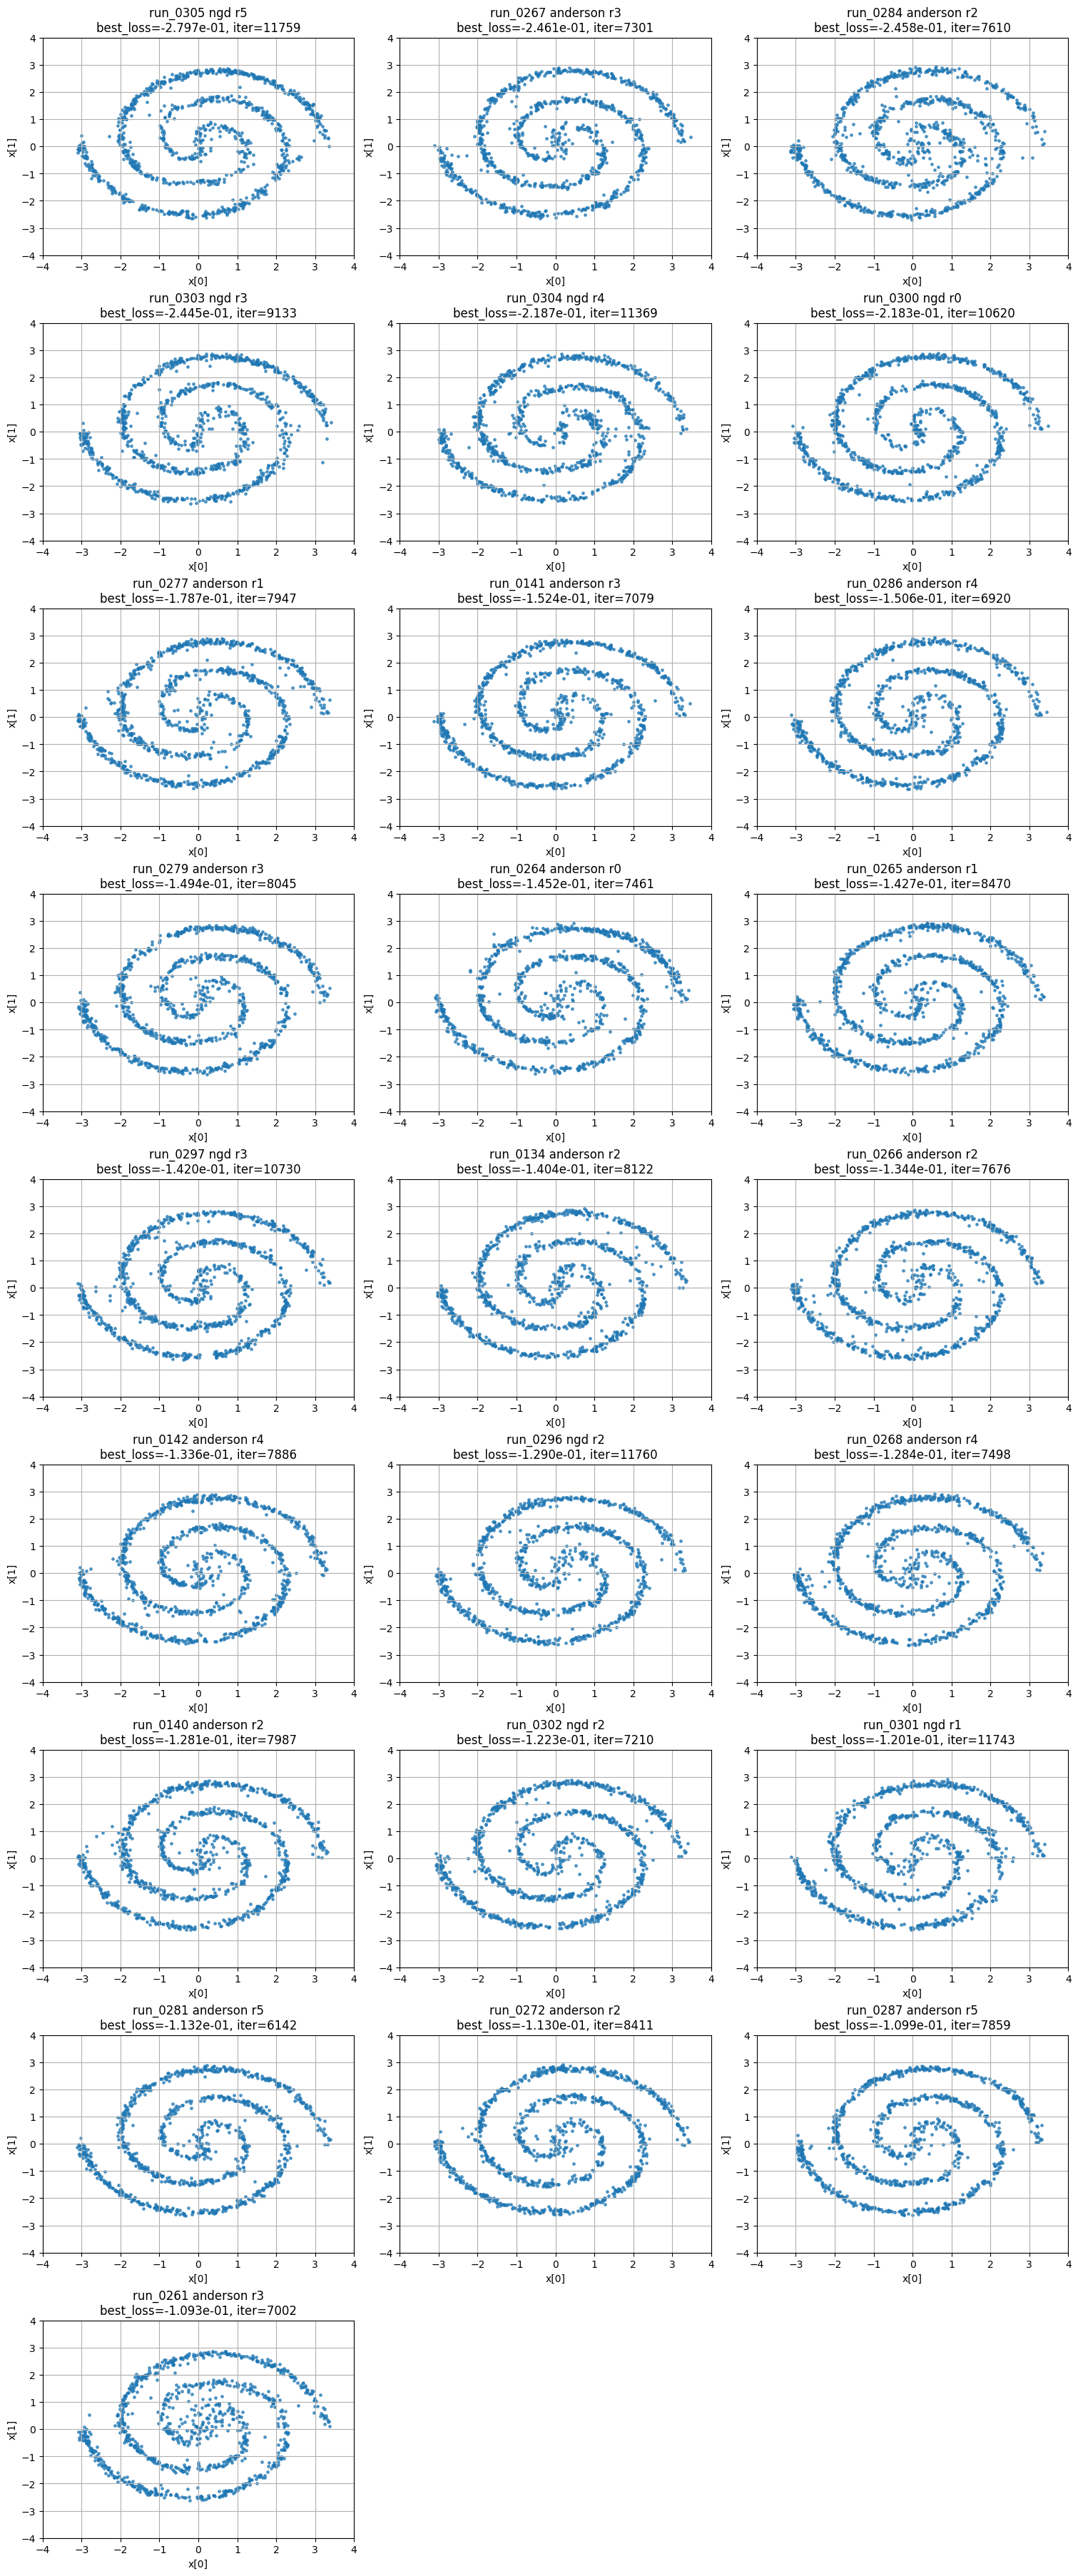

In [51]:
fig = scatter_best_entries(bes, checkpoint_key='best', n_samples=1024)
plt.show()
fig.savefig("best_scatters.pdf")

In [ ]:
best_entries[-3]

In [ ]:
df_all = entries_to_frame(entries)

In [ ]:
df_best_run = df_all.loc[120:125, ...]

In [ ]:
method_cols = [col for col in df_best_run.columns if "method_kwargs" in col]

In [ ]:
method_cols

In [ ]:
df_best_run[[
    'method_kwargs.natural_grad_clipping_threshold',
     'method_kwargs.step_size',
     'method_kwargs.linear_solver_regularization']]

In [ ]:
df_diverged = df_all[df_all.isna().any(axis=1)]

In [ ]:
df_diverged['method_kwargs.regularization_method'].unique()

In [ ]:
df_all.query('method == "ngd" and `method_kwargs.step_size` == 0.01')[['method_kwargs.step_size', 'best_loss', 'best_iteration', 'final_loss']]

In [ ]:
df_all.query("`method_kwargs.regularization_method` == 'adaptive'")[['final_loss', 'best_loss']].count()

In [ ]:
df_all.shape

In [ ]:
144*2+18

In [ ]:
df_adaptive = df_all.query("`method_kwargs.regularization_method` == 'adaptive' and `method_kwargs.relaxation` == 1.0")
df_adaptive

In [ ]:
df_adaptive.loc[0, 'best_iteration']

In [ ]:
data = np.load(df_adaptive.loc[0, 'run_dir']/'arrays.npz')

In [ ]:
l = data['loss']

In [ ]:
plt.plot(l)

In [ ]:
np.argmin(l)

In [ ]:
l1 = l.copy()
l1[~np.isfinite(l)] = np.inf
np.argmin(l1)

In [ ]:
l[1070:1079]

In [ ]:
np.argmin(np.isfinite(l))

In [ ]:
5. > np.nan

In [ ]:
np.nan < np.nan

In [ ]:
df_adaptive['best_loss']